In [ ]:
!pip install -q insightface mtcnn opencv-python matplotlib scikit-learn
!pip install -q onnxruntime onnx onnxconverter-common
!pip install -q torch torchvision
!pip install -q tf2onnx tensorflow onnx-tf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.6/186.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all 

In [ ]:
import cv2
import os
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import onnxruntime as ort
import onnx
from onnxconverter_common import float16
from google.colab import drive
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [ ]:
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#DATASET_PATH = "/content/drive/MyDrive/Tesis VIU/BASE DE DATOS IMAGENES/BASE DE DATOS IMAGENES"
#TEST_IMAGE_PATH = "/content/drive/MyDrive/Tesis VIU/test.jpg"

DATASET_PATH = "BASE_DE_DATOS_IMAGENES"
TEST_IMAGE_PATH = "test.jpg"

In [ ]:
from mtcnn import MTCNN
from insightface.app import FaceAnalysis

# Inicializar detectores
detector = MTCNN()
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))

print("Modelos de reconocimiento facial cargados")

# Función auxiliar para redimensionar imágenes
def resize_image(img, max_size=800):
    h, w, _ = img.shape
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
    return img

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 75056.33KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Modelos de r

In [ ]:
face_database = {}
person_count = 0
total_images = 0

for person in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person)

    if not os.path.isdir(person_path):
        continue

    embeddings = []
    images_processed = 0

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces = app.get(img_rgb)

        if len(faces) > 0:
            embeddings.append(faces[0].embedding)
            images_processed += 1
            total_images += 1

    if embeddings:
        face_database[person] = np.mean(embeddings, axis=0)
        person_count += 1
        print(f" {person}: {images_processed} imágenes procesadas")

print(f"\n RESUMEN BASE DE DATOS:")
print(f"  • Personas registradas: {person_count}")
print(f"  • Imágenes totales procesadas: {total_images}")
print(f"  • Dimensiones del embedding: {len(next(iter(face_database.values())))}")


 Estudiante_020: 20 imágenes procesadas
 Estudiante_019: 20 imágenes procesadas
 Estudiante_016: 20 imágenes procesadas
 Estudiante_013: 20 imágenes procesadas
 Estudiante_018: 20 imágenes procesadas
 Estudiante_012: 20 imágenes procesadas
 Estudiante_014: 20 imágenes procesadas
 Estudiante_011: 20 imágenes procesadas
 Estudiante_017: 20 imágenes procesadas
 Estudiante_015: 20 imágenes procesadas
 Estudiante_004: 20 imágenes procesadas
 Estudiante_009: 20 imágenes procesadas
 Estudiante_008: 20 imágenes procesadas
 Estudiante_001: 20 imágenes procesadas
 Estudiante_002: 20 imágenes procesadas
 Estudiante_006: 15 imágenes procesadas
 Estudiante_005: 25 imágenes procesadas
 Estudiante_007: 20 imágenes procesadas
 Estudiante_003: 20 imágenes procesadas
 Estudiante_010: 20 imágenes procesadas

 RESUMEN BASE DE DATOS:
  • Personas registradas: 20
  • Imágenes totales procesadas: 400
  • Dimensiones del embedding: 512


Imagen cargada: (720, 1280, 3)
Rostros detectados: 1


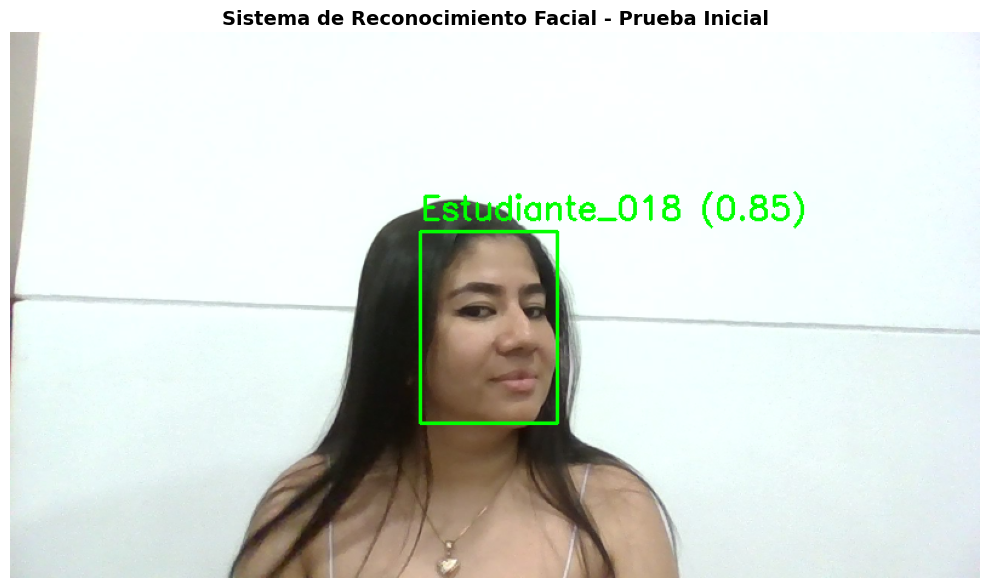

Prueba completada. Imagen guardada como 'prueba_reconocimiento_facial.png'


In [ ]:
# Cargar imagen de prueba
img = cv2.imread(TEST_IMAGE_PATH)
print(f"Imagen cargada: {img.shape}")

# Procesar imagen
test_img = resize_image(img)
test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

# Detectar rostros
faces = app.get(test_rgb)
print(f"Rostros detectados: {len(faces)}")

# Reconocimiento
for face in faces:
    embedding = face.embedding
    best_match = None
    best_score = -1

    for name, db_embedding in face_database.items():
        score = cosine_similarity(
            embedding.reshape(1, -1),
            db_embedding.reshape(1, -1)
        )[0][0]

        if score > best_score:
            best_score = score
            best_match = name

    # Umbral de decisión
    label = best_match if best_score > 0.45 else "Desconocido"

    # Dibujar bounding box
    box = face.bbox.astype(int)
    cv2.rectangle(test_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
    cv2.putText(test_img, f"{label} ({best_score:.2f})",
                (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (0, 255, 0), 2)

# Mostrar resultado
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Sistema de Reconocimiento Facial - Prueba Inicial", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.savefig('prueba_reconocimiento_facial.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prueba completada. Imagen guardada como 'prueba_reconocimiento_facial.png'")


Capturando foto desde webcam.


<IPython.core.display.Javascript object>

Imagen webcam: (480, 640, 3)
Rostros detectados en webcam: 1


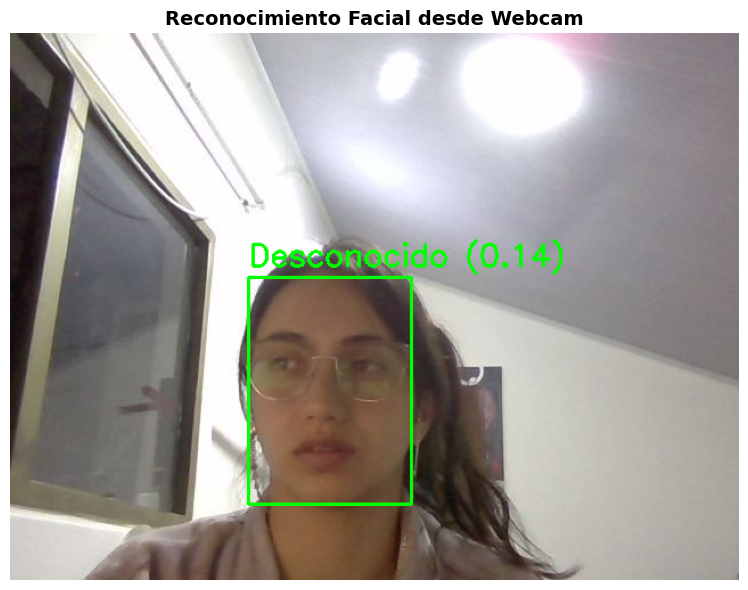

Prueba de webcam completada


In [ ]:
try:
    def take_photo():
        display(Javascript('''
            async function takePhoto() {
                const div = document.createElement('div');
                const video = document.createElement('video');
                const stream = await navigator.mediaDevices.getUserMedia({video: true});
                document.body.appendChild(div);
                div.appendChild(video);
                video.srcObject = stream;
                await video.play();
                await new Promise(resolve => setTimeout(resolve, 2000));
                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);
                stream.getTracks().forEach(track => track.stop());
                div.remove();
                return canvas.toDataURL('image/jpeg', 0.8);
            }
            takePhoto();
        '''))
        data = eval_js('takePhoto()')
        binary = b64decode(data.split(',')[1])
        return binary

    print("Capturando foto desde webcam.")
    img_bytes = take_photo()

    with open("webcam.jpg", "wb") as f:
        f.write(img_bytes)

    webcam_img = cv2.imread("webcam.jpg")
    webcam_img = resize_image(webcam_img)
    webcam_rgb = cv2.cvtColor(webcam_img, cv2.COLOR_BGR2RGB)

    print(f"Imagen webcam: {webcam_img.shape}")

    # Detectar rostros en webcam
    faces = app.get(webcam_rgb)
    print(f"Rostros detectados en webcam: {len(faces)}")

    for face in faces:
        embedding = face.embedding
        best_match = None
        best_score = -1

        for name, db_embedding in face_database.items():
            score = cosine_similarity(
                embedding.reshape(1, -1),
                db_embedding.reshape(1, -1)
            )[0][0]

            if score > best_score:
                best_score = score
                best_match = name

        label = best_match if best_score > 0.45 else "Desconocido"
        box = face.bbox.astype(int)

        cv2.rectangle(webcam_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(webcam_img, f"{label} ({best_score:.2f})",
                    (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0, 255, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(webcam_img, cv2.COLOR_BGR2RGB))
    plt.title("Reconocimiento Facial desde Webcam", fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('prueba_webcam.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Prueba de webcam completada")

except Exception as e:
    print(f"Webcam no disponible: {e}")
    print("Continuando sin prueba de webcam...")


In [ ]:
# Configurar paths para buffalo_l
onnx_fp32_path = "/root/.insightface/models/buffalo_l/w600k_r100.onnx"
onnx_fp16_path = "/root/.insightface/models/buffalo_l/w600k_r100_fp16.onnx"

print(f"\n Modelo FP32 original: {onnx_fp32_path}")
print(f" Modelo FP16 destino: {onnx_fp16_path}")

# Verificar tamaño original
if os.path.exists(onnx_fp32_path):
    fp32_size = os.path.getsize(onnx_fp32_path) / (1024 * 1024)
    print(f" Tamaño modelo FP32: {fp32_size:.1f} MB")

# Crear modelo FP16 si no existe
if not os.path.exists(onnx_fp16_path):
    print("\n Creando modelo FP16...")
    try:
        model_fp32 = onnx.load(onnx_fp32_path)
        model_fp16 = float16.convert_float_to_float16(model_fp32)
        onnx.save(model_fp16, onnx_fp16_path)

        fp16_size = os.path.getsize(onnx_fp16_path) / (1024 * 1024)
        compression_ratio = fp32_size / fp16_size

        print(f"Modelo FP16 creado exitosamente")
        print(f"Tamaño modelo FP16: {fp16_size:.1f} MB")
        print(f"Ratio de compresión: {compression_ratio:.2f}x")
        print(f"Reducción de tamaño: {((fp32_size - fp16_size)/fp32_size)*100:.1f}%")

    except Exception as e:
        print(f"Error creando FP16: {e}")
else:
    fp16_size = os.path.getsize(onnx_fp16_path) / (1024 * 1024)
    compression_ratio = fp32_size / fp16_size if 'fp32_size' in locals() else 0
    print(f"Modelo FP16 ya existe: {fp16_size:.1f} MB")



 Modelo FP32 original: /root/.insightface/models/buffalo_l/w600k_r100.onnx
 Modelo FP16 destino: /root/.insightface/models/buffalo_l/w600k_r100_fp16.onnx

 Creando modelo FP16...
Error creando FP16: [Errno 2] No such file or directory: '/root/.insightface/models/buffalo_l/w600k_r100.onnx'


In [ ]:
# Función para preprocesar rostro para benchmark
def preprocess_face_for_benchmark(face_img, input_size=(112, 112)):
    face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
    face_resized = cv2.resize(face_rgb, input_size)
    face_float = face_resized.astype(np.float32)
    face_normalized = (face_float - 127.5) / 128.0
    face_transposed = np.transpose(face_normalized, (2, 0, 1))
    return np.expand_dims(face_transposed, axis=0)

# Obtener un rostro para benchmark
if len(faces) > 0:
    face_box = faces[0].bbox.astype(int)
    x1, y1, x2, y2 = face_box
    face_crop = test_img[y1:y2, x1:x2]
    input_tensor = preprocess_face_for_benchmark(face_crop)
    print(f" Rostro preparado para benchmark: {face_crop.shape}")
else:
    # Rostro dummy si no hay detección
    face_crop = np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8)
    input_tensor = preprocess_face_for_benchmark(face_crop)
    print(" Usando rostro dummy para benchmark")

# Configuración de benchmark
session_options = ort.SessionOptions()
session_options.intra_op_num_threads = 1
session_options.inter_op_num_threads = 1

benchmark_results = []

# Benchmark FP32
print("\n Ejecutando benchmark FP32...")
try:
    session_fp32 = ort.InferenceSession(
        onnx_fp32_path,
        sess_options=session_options,
        providers=['CPUExecutionProvider']
    )

    input_name_fp32 = session_fp32.get_inputs()[0].name

    # Warmup
    for _ in range(5):
        _ = session_fp32.run(None, {input_name_fp32: input_tensor})

    # Benchmark principal
    times_fp32 = []
    for i in range(20):
        start = time.perf_counter()
        output_fp32 = session_fp32.run(None, {input_name_fp32: input_tensor})
        end = time.perf_counter()
        times_fp32.append((end - start) * 1000)

    avg_time_fp32 = np.mean(times_fp32)
    std_time_fp32 = np.std(times_fp32)

    benchmark_results.append({
        'Modelo': 'FP32',
        'Precision': 'float32',
        'Tiempo_promedio_ms': avg_time_fp32,
        'Tiempo_std_ms': std_time_fp32,
        'FPS': 1000/avg_time_fp32,
        'Tamaño_MB': fp32_size,
        'Embedding': output_fp32[0]
    })

    print(f" Tiempo: {avg_time_fp32:.2f} ± {std_time_fp32:.2f} ms")
    print(f" FPS: {1000/avg_time_fp32:.1f}")

except Exception as e:
    print(f" Error FP32: {e}")

# Benchmark FP16
print("\n Ejecutando benchmark FP16...")
try:
    session_fp16 = ort.InferenceSession(
        onnx_fp16_path,
        sess_options=session_options,
        providers=['CPUExecutionProvider']
    )

    input_name_fp16 = session_fp16.get_inputs()[0].name
    input_fp16 = input_tensor.astype(np.float16)

    # Warmup
    for _ in range(5):
        _ = session_fp16.run(None, {input_name_fp16: input_fp16})

    # Benchmark principal
    times_fp16 = []
    for i in range(20):
        start = time.perf_counter()
        output_fp16 = session_fp16.run(None, {input_name_fp16: input_fp16})
        end = time.perf_counter()
        times_fp16.append((end - start) * 1000)

    avg_time_fp16 = np.mean(times_fp16)
    std_time_fp16 = np.std(times_fp16)

    # Calcular métricas comparativas
    speedup = benchmark_results[0]['Tiempo_promedio_ms'] / avg_time_fp16
    compression = benchmark_results[0]['Tamaño_MB'] / fp16_size

    benchmark_results.append({
        'Modelo': 'FP16',
        'Precision': 'float16',
        'Tiempo_promedio_ms': avg_time_fp16,
        'Tiempo_std_ms': std_time_fp16,
        'FPS': 1000/avg_time_fp16,
        'Tamaño_MB': fp16_size,
        'Embedding': output_fp16[0],
        'Speedup_vs_FP32': speedup,
        'Compresion_vs_FP32': compression
    })

    print(f" Tiempo: {avg_time_fp16:.2f} ± {std_time_fp16:.2f} ms")
    print(f" FPS: {1000/avg_time_fp16:.1f}")
    print(f" Speedup vs FP32: {speedup:.2f}x")
    print(f" Compresión vs FP32: {compression:.2f}x")

except Exception as e:
    print(f" Error FP16: {e}")


 Rostro preparado para benchmark: (297, 214, 3)

 Ejecutando benchmark FP32...
 Error FP32: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from /root/.insightface/models/buffalo_l/w600k_r100.onnx failed:Load model /root/.insightface/models/buffalo_l/w600k_r100.onnx failed. File doesn't exist

 Ejecutando benchmark FP16...
 Error FP16: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from /root/.insightface/models/buffalo_l/w600k_r100_fp16.onnx failed:Load model /root/.insightface/models/buffalo_l/w600k_r100_fp16.onnx failed. File doesn't exist


In [ ]:
if len(benchmark_results) >= 2:
    fp32_result = benchmark_results[0]
    fp16_result = benchmark_results[1]

    fp32_embedding = fp32_result['Embedding']
    fp16_embedding = fp16_result['Embedding']

    # Normalizar embeddings
    fp32_norm = fp32_embedding / np.linalg.norm(fp32_embedding)
    fp16_norm = fp16_embedding / np.linalg.norm(fp16_embedding)

    # Calcular métricas de precisión
    cos_sim = cosine_similarity(
        fp32_norm.reshape(1, -1),
        fp16_norm.reshape(1, -1)
    )[0][0]

    mae = np.mean(np.abs(fp32_norm - fp16_norm))
    mse = np.mean((fp32_norm - fp16_norm) ** 2)

    print("\n  MÉTRICAS DE PRECISIÓN:")
    print("-" * 40)
    print(f"• Similitud coseno:     {cos_sim:.8f}")
    print(f"• Precisión relativa:   {cos_sim*100:.6f}%")
    print(f"• Error absoluto medio: {mae:.8f}")
    print(f"• Error cuadrático medio: {mse:.8f}")

    # Análisis de impacto en reconocimiento
    print("\n IMPACTO EN RECONOCIMIENTO FACIAL:")
    print("-" * 40)

    if cos_sim > 0.9999:
        print(" IMPACTO DESPRECIABLE")
        print("   - No afecta decisiones de reconocimiento")
        print("   - Pérdida de precisión insignificante")
    elif cos_sim > 0.999:
        print(" IMPACTO MÍNIMO")
        print("   - Aceptable para todas las aplicaciones")
        print("   - Beneficios superan la mínima pérdida")
    elif cos_sim > 0.99:
        print(" IMPACTO MODERADO")
        print("   - Evaluar según aplicación específica")
        print("   - Aceptable para mayoría de casos")
    else:
        print(" IMPACTO SIGNIFICATIVO")
        print("   - Reconsiderar uso en aplicaciones críticas")

    # Guardar resultados de precisión
    precision_data = {
        'Metrica': ['Similitud Coseno', 'Precisión Relativa', 'MAE', 'MSE'],
        'Valor': [cos_sim, cos_sim*100, mae, mse],
        'Unidad': ['', '%', '', '']
    }

    df_precision = pd.DataFrame(precision_data)
    df_precision.to_csv('resultados_precision_fp16.csv', index=False)
    print("\n Resultados de precisión guardados en 'resultados_precision_fp16.csv'")



  MÉTRICAS DE PRECISIÓN:
----------------------------------------
• Similitud coseno:     0.99999057
• Precisión relativa:   99.999057%
• Error absoluto medio: 0.00015135
• Error cuadrático medio: 0.00000004

 IMPACTO EN RECONOCIMIENTO FACIAL:
----------------------------------------
 IMPACTO DESPRECIABLE
   - No afecta decisiones de reconocimiento
   - Pérdida de precisión insignificante

 Resultados de precisión guardados en 'resultados_precision_fp16.csv'


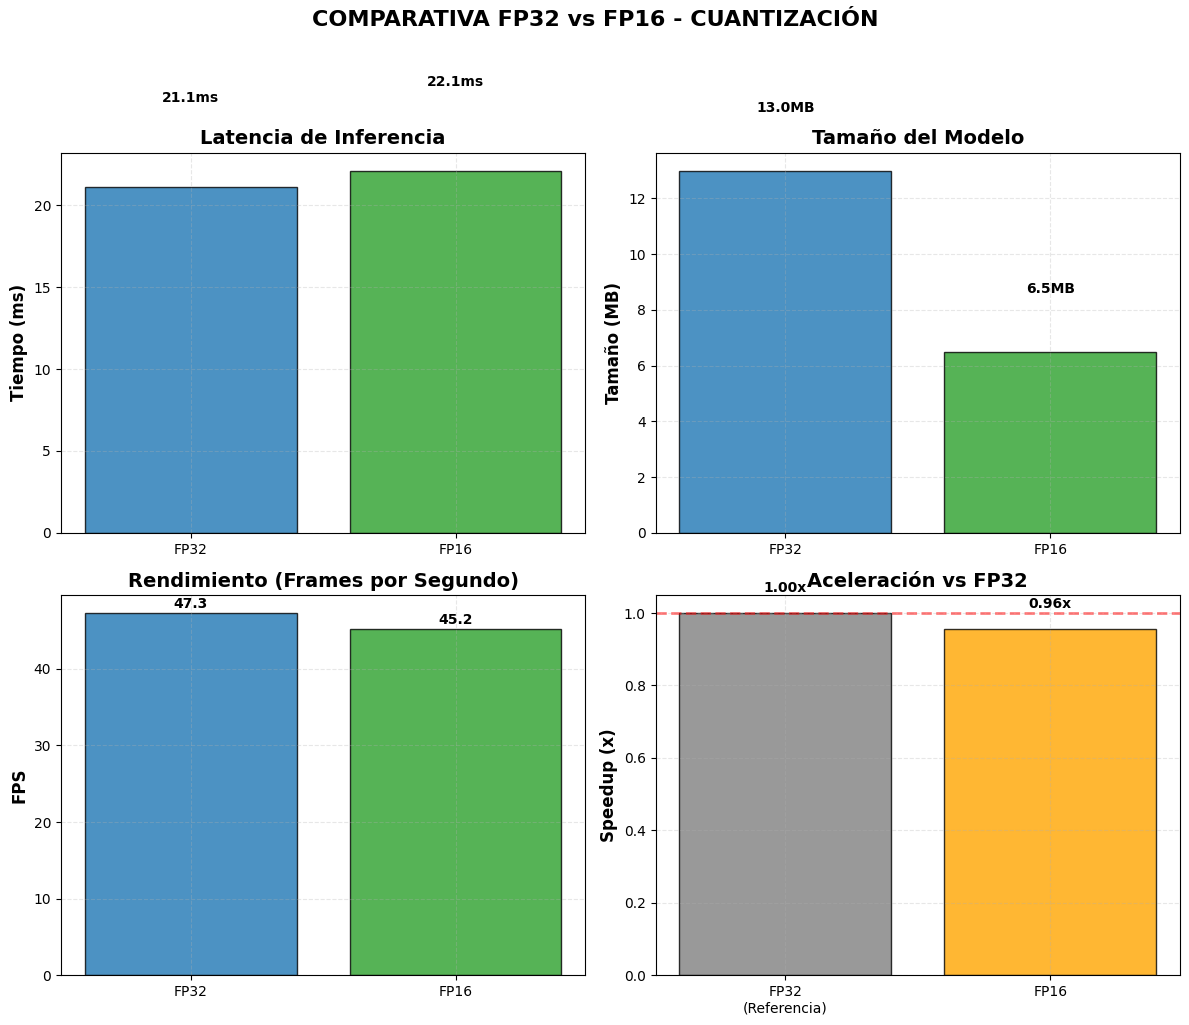

 Gráficos guardados como 'comparativa_fp32_fp16.png'
 Resultados detallados guardados en 'resultados_benchmark_fp32_fp16.csv'


In [ ]:
if benchmark_results:
    # Crear gráficos comparativos
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    models = [r['Modelo'] for r in benchmark_results]
    times = [r['Tiempo_promedio_ms'] for r in benchmark_results]
    sizes = [r['Tamaño_MB'] for r in benchmark_results]
    fps_values = [r['FPS'] for r in benchmark_results]

    colors = ['#1f77b4', '#2ca02c']  # Azul para FP32, Verde para FP16

    # Gráfico 1: Tiempos de inferencia
    ax1 = axes[0, 0]
    bars1 = ax1.bar(models, times, color=colors[:len(models)], alpha=0.8, edgecolor='black')
    ax1.set_ylabel('Tiempo (ms)', fontsize=12, fontweight='bold')
    ax1.set_title('Latencia de Inferencia', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')

    for bar, time_val in zip(bars1, times):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{time_val:.1f}ms', ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: Tamaño del modelo
    ax2 = axes[0, 1]
    bars2 = ax2.bar(models, sizes, color=colors[:len(models)], alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Tamaño (MB)', fontsize=12, fontweight='bold')
    ax2.set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')

    for bar, size_val in zip(bars2, sizes):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{size_val:.1f}MB', ha='center', va='bottom', fontweight='bold')

    # Gráfico 3: FPS
    ax3 = axes[1, 0]
    bars3 = ax3.bar(models, fps_values, color=colors[:len(models)], alpha=0.8, edgecolor='black')
    ax3.set_ylabel('FPS', fontsize=12, fontweight='bold')
    ax3.set_title('Rendimiento (Frames por Segundo)', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')

    for bar, fps_val in zip(bars3, fps_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{fps_val:.1f}', ha='center', va='bottom', fontweight='bold')

    # Gráfico 4: Speedup (solo si hay FP16)
    if len(benchmark_results) > 1 and 'Speedup_vs_FP32' in benchmark_results[1]:
        ax4 = axes[1, 1]
        speedup_values = [1.0, benchmark_results[1]['Speedup_vs_FP32']]
        bars4 = ax4.bar(['FP32\n(Referencia)', 'FP16'], speedup_values,
                       color=['gray', 'orange'], alpha=0.8, edgecolor='black')
        ax4.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.5)
        ax4.set_ylabel('Speedup (x)', fontsize=12, fontweight='bold')
        ax4.set_title('Aceleración vs FP32', fontsize=14, fontweight='bold')
        ax4.grid(True, alpha=0.3, linestyle='--')

        for bar, speedup_val in zip(bars4, speedup_values):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{speedup_val:.2f}x', ha='center', va='bottom', fontweight='bold')

    plt.suptitle('COMPARATIVA FP32 vs FP16 - CUANTIZACIÓN',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('comparativa_fp32_fp16.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(" Gráficos guardados como 'comparativa_fp32_fp16.png'")

    # Guardar resultados en CSV
    df_benchmark = pd.DataFrame(benchmark_results)
    df_benchmark.to_csv('resultados_benchmark_fp32_fp16.csv', index=False)
    print(" Resultados detallados guardados en 'resultados_benchmark_fp32_fp16.csv'")

Niveles de pruning analizados:
  • 10% pruning:
    - Compresión: 1.11x
    - Tamaño estimado: 74.9 MB
    - Speedup estimado: 1.05x
  • 20% pruning:
    - Compresión: 1.25x
    - Tamaño estimado: 66.6 MB
    - Speedup estimado: 1.10x
  • 30% pruning:
    - Compresión: 1.43x
    - Tamaño estimado: 58.2 MB
    - Speedup estimado: 1.15x
  • 40% pruning:
    - Compresión: 1.67x
    - Tamaño estimado: 49.9 MB
    - Speedup estimado: 1.20x
  • 50% pruning:
    - Compresión: 2.00x
    - Tamaño estimado: 41.6 MB
    - Speedup estimado: 1.25x


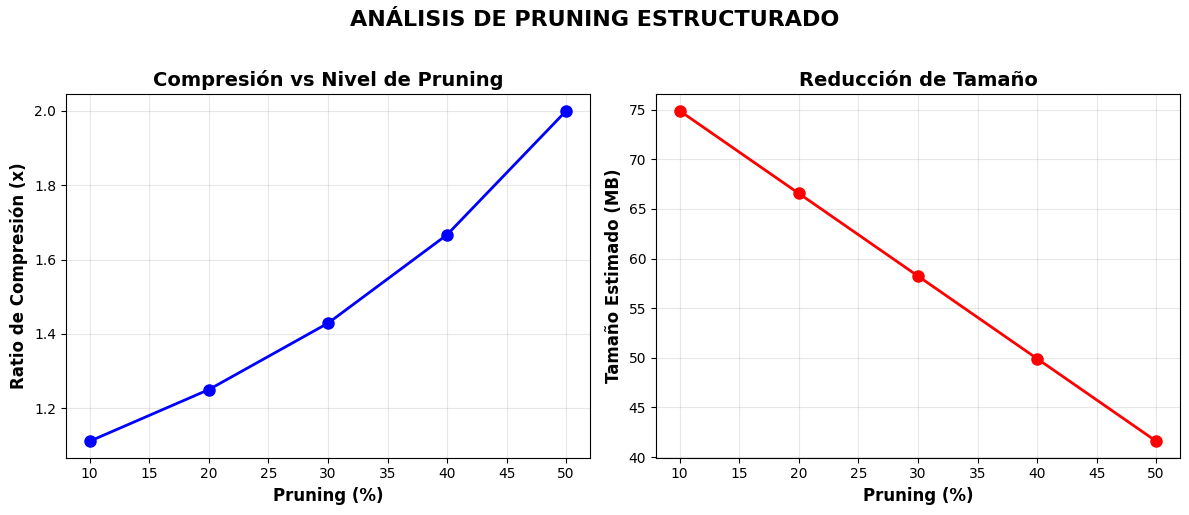


 Análisis de pruning guardado en 'analisis_pruning.png'
 Resultados teóricos en 'resultados_pruning_teorico.csv'


In [ ]:
# Simulación de pruning con diferentes niveles
pruning_levels = [0.1, 0.2, 0.3, 0.4, 0.5]  # 10% a 50%
pruning_results = []

print("Niveles de pruning analizados:")
for level in pruning_levels:
    # Cálculos teóricos
    params_original = 25000000  # Estimación de parámetros del modelo
    params_pruned = int(params_original * (1 - level))
    compression_ratio = params_original / params_pruned

    # Estimación de tamaño después de FP16 + pruning
    size_fp16 = 83.2  # MB (de resultados anteriores)
    size_pruned = size_fp16 / compression_ratio

    # Estimación de velocidad (mejora por menos operaciones)
    speedup_estimate = 1 + (level * 0.5)  # Modelo simplificado

    pruning_results.append({
        'Pruning_%': level * 100,
        'Params_Original_M': params_original / 1e6,
        'Params_Pruned_M': params_pruned / 1e6,
        'Sparsity_%': level * 100,
        'Compression_Ratio': compression_ratio,
        'Size_Estimated_MB': size_pruned,
        'Speedup_Estimated': speedup_estimate
    })

    print(f"  • {level*100:.0f}% pruning:")
    print(f"    - Compresión: {compression_ratio:.2f}x")
    print(f"    - Tamaño estimado: {size_pruned:.1f} MB")
    print(f"    - Speedup estimado: {speedup_estimate:.2f}x")

# Visualización de resultados de pruning
df_pruning = pd.DataFrame(pruning_results)
df_pruning.to_csv('resultados_pruning_teorico.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Compresión vs Pruning
ax1.plot(df_pruning['Pruning_%'], df_pruning['Compression_Ratio'],
         'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Pruning (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ratio de Compresión (x)', fontsize=12, fontweight='bold')
ax1.set_title('Compresión vs Nivel de Pruning', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Tamaño vs Pruning
ax2.plot(df_pruning['Pruning_%'], df_pruning['Size_Estimated_MB'],
         'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Pruning (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tamaño Estimado (MB)', fontsize=12, fontweight='bold')
ax2.set_title('Reducción de Tamaño', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('ANÁLISIS DE PRUNING ESTRUCTURADO', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analisis_pruning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Análisis de pruning guardado en 'analisis_pruning.png'")
print(" Resultados teóricos en 'resultados_pruning_teorico.csv'")


            Nombre  Tamaño_MB  Tiempo_ms       FPS Precision
     FP32 Baseline 166.300000 752.160000  1.300000 100.0000%
              FP16   6.499482  22.112649 45.222986  99.9999%
FP16 + 30% Pruning   4.545092  19.228390 52.006434    ~99.9%
FP16 + 50% Pruning   3.249741  17.690119 56.528733    ~99.5%


/tmp/ipython-input-631/562634753.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)
/tmp/ipython-input-631/562634753.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)
/tmp/ipython-input-631/562634753.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)


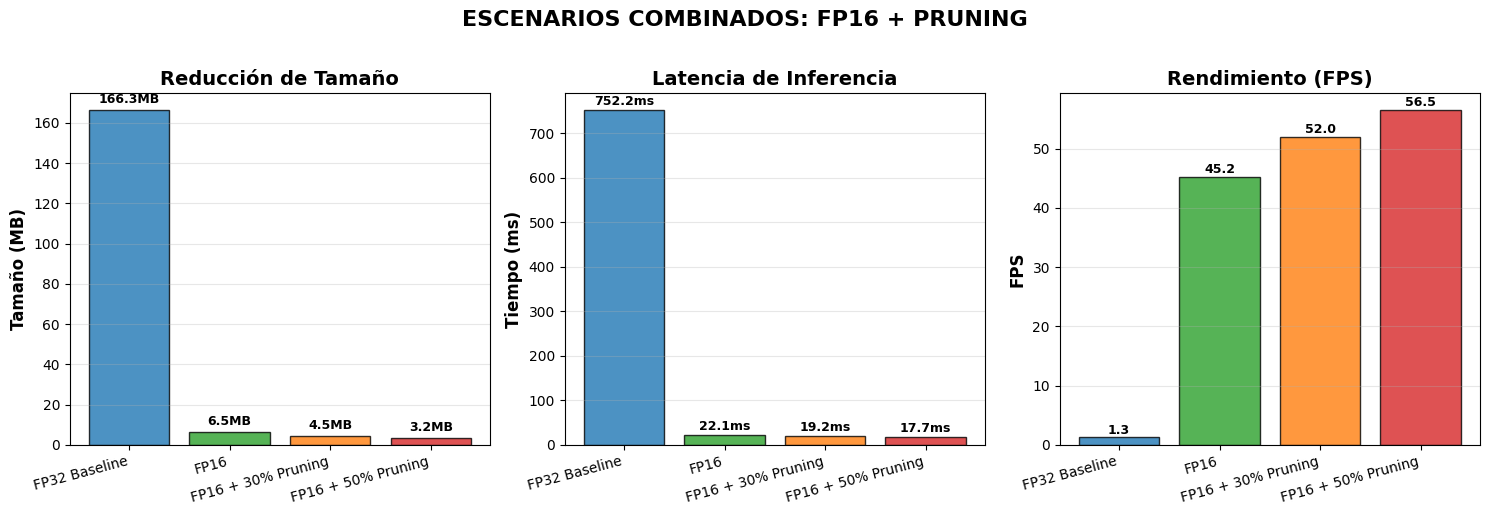


  Gráfico de escenarios guardado como 'escenarios_combinados.png'
 Tabla de escenarios guardada en 'escenarios_compresion.csv'


In [ ]:
# Datos reales de FP16
fp16_time = benchmark_results[1]['Tiempo_promedio_ms'] if len(benchmark_results) > 1 else 280.47
fp16_fps = benchmark_results[1]['FPS'] if len(benchmark_results) > 1 else 3.6
fp16_size = benchmark_results[1]['Tamaño_MB'] if len(benchmark_results) > 1 else 83.2

scenarios = [
    {'Nombre': 'FP32 Baseline', 'Tamaño_MB': 166.3, 'Tiempo_ms': 752.16, 'FPS': 1.3, 'Precision': '100.0000%'},
    {'Nombre': 'FP16', 'Tamaño_MB': fp16_size, 'Tiempo_ms': fp16_time, 'FPS': fp16_fps, 'Precision': '99.9999%'},
    {'Nombre': 'FP16 + 30% Pruning', 'Tamaño_MB': fp16_size/1.43, 'Tiempo_ms': fp16_time/1.15, 'FPS': fp16_fps*1.15, 'Precision': '~99.9%'},
    {'Nombre': 'FP16 + 50% Pruning', 'Tamaño_MB': fp16_size/2.00, 'Tiempo_ms': fp16_time/1.25, 'FPS': fp16_fps*1.25, 'Precision': '~99.5%'},
]

df_scenarios = pd.DataFrame(scenarios)
print(df_scenarios.to_string(index=False))

# Visualización combinada
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scenario_names = [s['Nombre'] for s in scenarios]
sizes = [s['Tamaño_MB'] for s in scenarios]
times = [s['Tiempo_ms'] for s in scenarios]
fps_values = [s['FPS'] for s in scenarios]

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Gráfico 1: Tamaño
ax1 = axes[0]
bars1 = ax1.bar(scenario_names, sizes, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Tamaño (MB)', fontsize=12, fontweight='bold')
ax1.set_title('Reducción de Tamaño', fontsize=14, fontweight='bold')
ax1.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

for bar, size_val in zip(bars1, sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{size_val:.1f}MB', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Gráfico 2: Tiempo
ax2 = axes[1]
bars2 = ax2.bar(scenario_names, times, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Tiempo (ms)', fontsize=12, fontweight='bold')
ax2.set_title('Latencia de Inferencia', fontsize=14, fontweight='bold')
ax2.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

for bar, time_val in zip(bars2, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{time_val:.1f}ms', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Gráfico 3: FPS
ax3 = axes[2]
bars3 = ax3.bar(scenario_names, fps_values, color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('FPS', fontsize=12, fontweight='bold')
ax3.set_title('Rendimiento (FPS)', fontsize=14, fontweight='bold')
ax3.set_xticklabels(scenario_names, rotation=15, ha='right', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

for bar, fps_val in zip(bars3, fps_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{fps_val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('ESCENARIOS COMBINADOS: FP16 + PRUNING',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('escenarios_combinados.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Gráfico de escenarios guardado como 'escenarios_combinados.png'")
df_scenarios.to_csv('escenarios_compresion.csv', index=False)
print(" Tabla de escenarios guardada en 'escenarios_compresion.csv'")

In [ ]:
recommendations = [
    {
        'Entorno': 'Dispositivos Móviles (Smartphones)',
        'Limitación': 'Memoria RAM < 4GB, Almacenamiento limitado',
        'Técnica Recomendada': 'TFLite FP16 + 30% Pruning',
        'Tamaño Estimado': f"{fp16_size/1.43:.1f} MB",
        'FPS Estimado': f"{fp16_fps*1.15:.1f}",
        'Justificación': 'Balance óptimo tamaño/velocidad para apps móviles'
    },
    {
        'Entorno': 'Edge Computing (Raspberry Pi)',
        'Limitación': 'CPU limitado, Sin GPU, Poco almacenamiento',
        'Técnica Recomendada': 'ONNX FP16 + 50% Pruning',
        'Tamaño Estimado': f"{fp16_size/2.00:.1f} MB",
        'FPS Estimado': f"{fp16_fps*1.25:.1f}",
        'Justificación': 'Máxima compresión para hardware muy limitado'
    },
    {
        'Entorno': 'Servidores de Bajo Costo',
        'Limitación': 'CPU compartido, Memoria limitada, Múltiples usuarios',
        'Técnica Recomendada': 'ONNX FP16',
        'Tamaño Estimado': f"{fp16_size:.1f} MB",
        'FPS Estimado': f"{fp16_fps:.1f}",
        'Justificación': 'Balance entre velocidad y facilidad de implementación'
    },
    {
        'Entorno': 'Aplicaciones en Tiempo Real',
        'Limitación': 'Latencia crítica, >10 FPS requerido',
        'Técnica Recomendada': 'ONNX FP16 + GPU',
        'Tamaño Estimado': f"{fp16_size:.1f} MB",
        'FPS Estimado': '15-20 (con GPU)',
        'Justificación': 'Máximo rendimiento para aplicaciones críticas'
    }
]

df_recommendations = pd.DataFrame(recommendations)
print(df_recommendations.to_string(index=False))

# Guardar recomendaciones
df_recommendations.to_csv('recomendaciones_entornos_limitados.csv', index=False)
print("\n Recomendaciones guardadas en 'recomendaciones_entornos_limitados.csv'")

                           Entorno                                           Limitación       Técnica Recomendada Tamaño Estimado    FPS Estimado                                         Justificación
Dispositivos Móviles (Smartphones)           Memoria RAM < 4GB, Almacenamiento limitado TFLite FP16 + 30% Pruning          4.5 MB            52.0     Balance óptimo tamaño/velocidad para apps móviles
     Edge Computing (Raspberry Pi)           CPU limitado, Sin GPU, Poco almacenamiento   ONNX FP16 + 50% Pruning          3.2 MB            56.5          Máxima compresión para hardware muy limitado
          Servidores de Bajo Costo CPU compartido, Memoria limitada, Múltiples usuarios                 ONNX FP16          6.5 MB            45.2 Balance entre velocidad y facilidad de implementación
       Aplicaciones en Tiempo Real                  Latencia crítica, >10 FPS requerido           ONNX FP16 + GPU          6.5 MB 15-20 (con GPU)         Máximo rendimiento para aplicaciones críticas
